# Public API Quality Dashboard

이 노트북은 `public_raw`에 적재된 공공데이터 API 기반 raw가 실제 layer/score 근거로 쓸 수 있는지 확인한다.

공공데이터는 OSM보다 공식성은 높지만, API별 수집 방식과 전처리 기준이 다르다. 따라서 단순 row 수가 아니라 query_key, 수집 시점, 좌표 품질, 서울 범위, 결측, 중복, layer 반영률을 함께 본다.

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sqlalchemy import text

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEOUL_BBOX = {
    "min_lon": 126.7,
    "max_lon": 127.2,
    "min_lat": 37.4,
    "max_lat": 37.75,
}

KOREAN_FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")
if KOREAN_FONT_PATH.exists():
    fm.fontManager.addfont(str(KOREAN_FONT_PATH))
    KOREAN_FONT = fm.FontProperties(fname=str(KOREAN_FONT_PATH))
    KOREAN_FONT_NAME = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
    KOREAN_FONT_NAME = "DejaVu Sans"

sns.set_theme(style="whitegrid", font=KOREAN_FONT_NAME, rc={"axes.unicode_minus": False})
plt.rcParams["font.family"] = KOREAN_FONT_NAME
plt.rcParams["axes.unicode_minus"] = False


def apply_korean_font(ax):
    if KOREAN_FONT is None:
        return ax
    ax.title.set_fontproperties(KOREAN_FONT)
    ax.xaxis.label.set_fontproperties(KOREAN_FONT)
    ax.yaxis.label.set_fontproperties(KOREAN_FONT)
    for text in ax.get_xticklabels() + ax.get_yticklabels() + ax.texts:
        text.set_fontproperties(KOREAN_FONT)
    return ax


def add_point_quality_columns(gdf):
    result = gdf.copy()
    result["lon"] = result.geometry.x
    result["lat"] = result.geometry.y
    result["within_seoul_bbox"] = (
        result["lon"].between(SEOUL_BBOX["min_lon"], SEOUL_BBOX["max_lon"])
        & result["lat"].between(SEOUL_BBOX["min_lat"], SEOUL_BBOX["max_lat"])
    )
    result["lon_round6"] = result["lon"].round(6)
    result["lat_round6"] = result["lat"].round(6)
    return result


from src.database.postgresql import engine

FIGURE_DIR = PROJECT_ROOT / "analysis" / "figures" / "raw" / "public_api"
TABLE_DIR = PROJECT_ROOT / "analysis" / "tables" / "raw" / "public_api"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

## 1. public_raw 적재 상태 확인

`public_raw`에 어떤 API 결과가 들어와 있는지 query_key 기준으로 확인한다.

여기서 알 수 있는 것:
- 어떤 공공 API raw가 DB에 존재하는지
- API별 row 수 편차가 큰지
- geometry가 누락되지 않았는지
- DB에 언제 적재했는지

주의할 점: `fetched_at`은 DB 적재 시점이고, 원천 공공데이터의 기준일/갱신일은 별도 metadata가 있어야 검증할 수 있다.

In [3]:
public_status_sql = '''
SELECT
    query_key,
    COUNT(*) AS row_count,
    COUNT(geom) AS geom_count,
    MIN(fetched_at) AS first_fetched_at,
    MAX(fetched_at) AS last_fetched_at
FROM public_raw
GROUP BY query_key
ORDER BY row_count DESC
'''

try:
    public_status = pd.read_sql(public_status_sql, engine)
    display(public_status)
    public_status.to_csv(TABLE_DIR / "public_raw_query_key_status.csv", index=False, encoding="utf-8-sig")
except Exception as e:
    public_status = pd.DataFrame()
    print("public_raw 조회 실패:", e)

,query_key,row_count,geom_count,first_fetched_at,last_fetched_at
0,type=play_facility,7066,7066,2026-06-24 09:42:45.448586,2026-06-24 09:42:45.448586
1,type=landmark,660,660,2026-06-24 09:43:00.395244,2026-06-24 09:43:00.395244


## 2. public_raw GeoDataFrame 로드

`public_raw`의 point geometry와 properties를 함께 불러온다. 이후 분석은 이 GeoDataFrame을 기준으로 진행한다.

In [4]:
public_sql = '''
SELECT
    id AS public_raw_id,
    query_key,
    properties,
    fetched_at,
    geom
FROM public_raw
'''

try:
    public_gdf = gpd.read_postgis(public_sql, engine, geom_col="geom", crs="EPSG:4326")
    print("public_raw rows:", len(public_gdf))
    display(public_gdf.head())
except Exception as e:
    public_gdf = gpd.GeoDataFrame()
    print("public_raw GeoDataFrame 로드 실패:", e)

public_raw rows: 7726


,public_raw_id,query_key,properties,fetched_at,geom
0,1,type=play_facility,"{'name': '디에이치 방배 어린이놀이터3 (123동 128동 사이)', 'ad...",2026-06-24 09:42:45.448586,POINT (126.98986 37.48384)
1,2,type=play_facility,"{'name': '디에이치 방배 어린이놀이터4 (118동 옆)', 'address'...",2026-06-24 09:42:45.448586,POINT (126.99079 37.48401)
2,3,type=play_facility,"{'name': '디에이치 방배 유아놀이터 (115동 옆)', 'address': ...",2026-06-24 09:42:45.448586,POINT (126.98974 37.48350)
3,4,type=play_facility,"{'name': '디에이치 방배 어린이놀이터1 (109동 111동 사이)', 'ad...",2026-06-24 09:42:45.448586,POINT (126.98810 37.48437)
4,5,type=play_facility,"{'name': '힐스테이트 마포더퍼스트 어린이놀이터2', 'address': '서...",2026-06-24 09:42:45.448586,POINT (126.93472 37.54813)


## 3. query_key별 row 수 시각화

공공 API raw가 어떤 데이터셋에 집중되어 있는지 본다. row 수가 큰 데이터셋은 score에 과도하게 영향을 줄 수 있으므로, 이후에는 자치구별 density 또는 layer별 정규화 기준이 필요하다.

,query_key,row_count
1,type=play_facility,7066
0,type=landmark,660


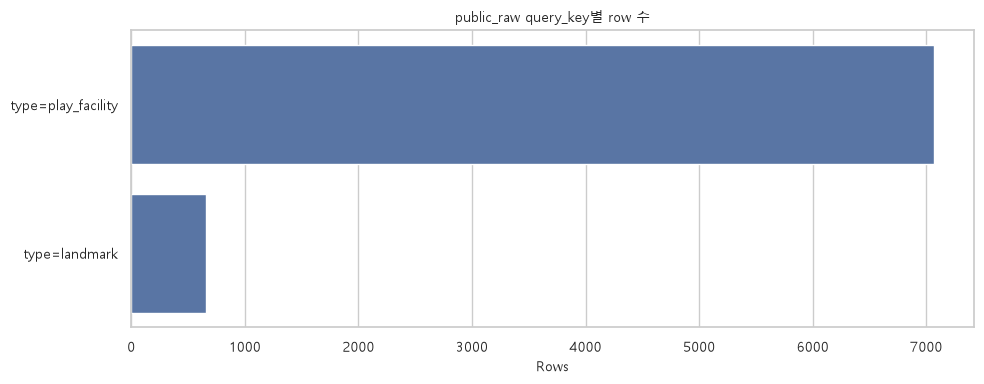

In [5]:
if public_gdf.empty:
    print("public_raw가 비어 있어 query_key 분포를 그릴 수 없습니다.")
else:
    public_query_counts = (
        public_gdf.groupby("query_key")
        .size()
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
    )
    display(public_query_counts)
    public_query_counts.to_csv(TABLE_DIR / "public_query_key_row_count.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=public_query_counts, x="row_count", y="query_key")
    ax.set_title("public_raw query_key별 row 수")
    ax.set_xlabel("Rows")
    ax.set_ylabel("")
    apply_korean_font(ax)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "public_query_key_row_count.png", dpi=160)
    plt.show()

## 4. properties 컬럼 구조 확인

공공 API별 응답에서 어떤 설명 컬럼이 남아 있는지 확인한다. 이름, 주소 같은 해석용 컬럼이 충분한지 보고 score 직접 컬럼과 보조 해석 컬럼을 구분한다.

In [6]:
if public_gdf.empty:
    public_flat = pd.DataFrame()
    public_prop_counts = pd.DataFrame()
    print("public_raw가 비어 있습니다.")
else:
    public_props = pd.json_normalize(public_gdf["properties"].apply(lambda x: x or {}).tolist())
    public_flat = pd.concat(
        [public_gdf.drop(columns=["properties"]).reset_index(drop=True), public_props],
        axis=1,
    )

    public_prop_counts = (
        public_props.notna()
        .sum()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "property", 0: "non_null_rows"})
    )

    print("properties columns:", len(public_props.columns))
    display(public_flat.head())
    display(public_prop_counts.head(40))
    public_prop_counts.to_csv(TABLE_DIR / "public_property_non_null_counts.csv", index=False, encoding="utf-8-sig")

properties columns: 2


,public_raw_id,query_key,fetched_at,geom,name,address
0,1,type=play_facility,2026-06-24 09:42:45.448586,POINT (126.98986 37.48384),디에이치 방배 어린이놀이터3 (123동 128동 사이),서울 서초구 방배중앙로7길 6
1,2,type=play_facility,2026-06-24 09:42:45.448586,POINT (126.99079 37.48401),디에이치 방배 어린이놀이터4 (118동 옆),서울 서초구 방배중앙로7길 6
2,3,type=play_facility,2026-06-24 09:42:45.448586,POINT (126.98974 37.48350),디에이치 방배 유아놀이터 (115동 옆),서울 서초구 방배중앙로7길 6
3,4,type=play_facility,2026-06-24 09:42:45.448586,POINT (126.98810 37.48437),디에이치 방배 어린이놀이터1 (109동 111동 사이),서울 서초구 방배중앙로7길 6
4,5,type=play_facility,2026-06-24 09:42:45.448586,POINT (126.93472 37.54813),힐스테이트 마포더퍼스트 어린이놀이터2,서울 마포구 신수로6길 12


,property,non_null_rows
0,name,7726
1,address,7726


## 5. 주요 설명 컬럼 결측률 확인

`name`, `address` 같은 설명 컬럼은 지도 tooltip, 해석 메모, 중복 검토에는 유용하다. 결측률이 크면 score 직접 사용보다 보조 해석용으로 제한한다.

In [7]:
if public_flat.empty:
    public_missing_summary = pd.DataFrame()
    print("public_flat이 비어 있습니다.")
else:
    core_cols = [c for c in ["name", "address"] if c in public_flat.columns]
    rows = []
    for query_key, group in public_flat.groupby("query_key"):
        for col in core_cols:
            missing_rate = float(group[col].isna().mean())
            rows.append({
                "query_key": query_key,
                "column": col,
                "missing_rows": int(group[col].isna().sum()),
                "missing_rate": missing_rate,
                "usage_note": "보조 해석 가능" if missing_rate <= 0.2 else "보조 해석 주의",
            })
    public_missing_summary = pd.DataFrame(rows)
    display(public_missing_summary)
    public_missing_summary.to_csv(TABLE_DIR / "public_core_column_missing_summary.csv", index=False, encoding="utf-8-sig")

,query_key,column,missing_rows,missing_rate,usage_note
0,type=landmark,name,0,0.0,보조 해석 가능
1,type=landmark,address,0,0.0,보조 해석 가능
2,type=play_facility,name,0,0.0,보조 해석 가능
3,type=play_facility,address,0,0.0,보조 해석 가능


## 6. geometry 품질 및 서울 bbox 포함 여부

공공 API raw는 point geometry로 저장된다. geometry null/invalid 여부와 서울 bbox 밖 좌표가 섞였는지 확인한다. bbox 검사는 정확한 행정경계 검사가 아니라 1차 이상치 탐지다.

In [8]:
if public_gdf.empty:
    public_geo_quality = pd.DataFrame()
    public_bbox_quality = pd.DataFrame()
    print("public_gdf가 비어 있습니다.")
else:
    public_points = add_point_quality_columns(public_gdf)

    public_geo_quality = pd.DataFrame([{
        "total_rows": len(public_points),
        "null_geometry_rows": int(public_points.geometry.isna().sum()),
        "valid_geometry_rows": int(public_points.geometry.is_valid.sum()),
        "invalid_geometry_rows": int((~public_points.geometry.is_valid).sum()),
        "within_seoul_bbox_rows": int(public_points["within_seoul_bbox"].sum()),
        "outside_seoul_bbox_rows": int((~public_points["within_seoul_bbox"]).sum()),
        "within_seoul_bbox_rate": float(public_points["within_seoul_bbox"].mean()),
    }])

    public_bbox_quality = public_points.groupby("query_key").agg(
        total_rows=("public_raw_id", "count"),
        within_seoul_bbox_rows=("within_seoul_bbox", "sum"),
    ).reset_index()
    public_bbox_quality["within_seoul_bbox_rate"] = (
        public_bbox_quality["within_seoul_bbox_rows"] / public_bbox_quality["total_rows"]
    )

    display(public_geo_quality)
    display(public_bbox_quality)
    public_geo_quality.to_csv(TABLE_DIR / "public_geometry_quality.csv", index=False, encoding="utf-8-sig")
    public_bbox_quality.to_csv(TABLE_DIR / "public_bbox_quality_by_query_key.csv", index=False, encoding="utf-8-sig")

,total_rows,null_geometry_rows,valid_geometry_rows,invalid_geometry_rows,within_seoul_bbox_rows,outside_seoul_bbox_rows,within_seoul_bbox_rate
0,7726,0,7726,0,7690,36,0.99534


,query_key,total_rows,within_seoul_bbox_rows,within_seoul_bbox_rate
0,type=landmark,660,659,0.998485
1,type=play_facility,7066,7031,0.995047


## 7. 좌표 중복 가능성 확인

같은 query_key 안에서 같은 좌표가 반복되면 같은 시설이 중복 저장되었을 가능성이 있다. 완전한 중복 판정은 아니고, 중복 후보를 찾는 1차 신호다.

In [9]:
if public_gdf.empty:
    public_duplicate_summary = pd.DataFrame()
    print("public_gdf가 비어 있습니다.")
else:
    public_points = add_point_quality_columns(public_gdf)
    public_points["coord_duplicate_in_query"] = public_points.duplicated(
        subset=["query_key", "lat_round6", "lon_round6"], keep=False
    )

    public_duplicate_summary = public_points.groupby("query_key").agg(
        total_rows=("public_raw_id", "count"),
        duplicate_coord_rows=("coord_duplicate_in_query", "sum"),
    ).reset_index()
    public_duplicate_summary["duplicate_coord_rate"] = (
        public_duplicate_summary["duplicate_coord_rows"] / public_duplicate_summary["total_rows"]
    )

    display(public_duplicate_summary.sort_values("duplicate_coord_rate", ascending=False))
    public_duplicate_summary.to_csv(TABLE_DIR / "public_duplicate_coord_summary.csv", index=False, encoding="utf-8-sig")

,query_key,total_rows,duplicate_coord_rows,duplicate_coord_rate
1,type=play_facility,7066,50,0.007076
0,type=landmark,660,0,0.000000


## 8. layer 반영률 확인

공공 API raw가 실제 layer에 반영되어 있는지 확인한다.

중요한 구분:
- `play_facility`는 `child_layer.public_raw_id`로 직접 연결 확인 가능
- `landmark`, `outdoor_exercise`, `accident_zone`은 현재 schema상 FK 연결이 없거나 불완전하므로 count 비교 중심으로만 확인

따라서 FK가 없는 항목은 “정확히 같은 row가 반영되었다”가 아니라 “규모가 맞는지” 정도로 해석한다.

In [10]:
public_layer_sql = '''
SELECT * FROM (
    SELECT
        'type=play_facility' AS query_key,
        (SELECT COUNT(*) FROM public_raw WHERE query_key = 'type=play_facility') AS raw_rows,
        (SELECT COUNT(*) FROM child_layer WHERE public_raw_id IS NOT NULL) AS layer_rows,
        'child_layer.public_raw_id FK' AS verification_method
    UNION ALL
    SELECT
        'type=landmark' AS query_key,
        (SELECT COUNT(*) FROM public_raw WHERE query_key = 'type=landmark') AS raw_rows,
        (SELECT COUNT(*) FROM landmark_layer) AS layer_rows,
        'count 비교: landmark_layer raw FK 없음' AS verification_method
    UNION ALL
    SELECT
        'type=outdoor_exercise' AS query_key,
        (SELECT COUNT(*) FROM public_raw WHERE query_key = 'type=outdoor_exercise') AS raw_rows,
        (SELECT COUNT(*) FROM running_layer WHERE course_type = 'outdoor_exercise') AS layer_rows,
        'count 비교: running_layer public_raw_id 없음' AS verification_method
    UNION ALL
    SELECT
        'type=accident_zone' AS query_key,
        (SELECT COUNT(*) FROM public_raw WHERE query_key = 'type=accident_zone') AS raw_rows,
        (SELECT COUNT(*) FROM safety_layer WHERE safety_type = 'accident_zone') AS layer_rows,
        'count 비교: safety_layer public_raw_id 없음' AS verification_method
) t
ORDER BY raw_rows DESC
'''

try:
    public_layer_reflection = pd.read_sql(public_layer_sql, engine)
    public_layer_reflection["reflection_rate"] = np.where(
        public_layer_reflection["raw_rows"] > 0,
        public_layer_reflection["layer_rows"] / public_layer_reflection["raw_rows"],
        np.nan,
    )
    display(public_layer_reflection)
    public_layer_reflection.to_csv(TABLE_DIR / "public_layer_reflection_summary.csv", index=False, encoding="utf-8-sig")
except Exception as e:
    public_layer_reflection = pd.DataFrame()
    print("layer 반영률 조회 실패:", e)

,query_key,raw_rows,layer_rows,verification_method,reflection_rate
0,type=play_facility,7066,7066,child_layer.public_raw_id FK,1.0
1,type=landmark,660,660,count 비교: landmark_layer raw FK 없음,1.0
2,type=outdoor_exercise,0,0,count 비교: running_layer public_raw_id 없음,NaN
3,type=accident_zone,0,0,count 비교: safety_layer public_raw_id 없음,NaN


## 9. 원천 최신성/거짓 데이터 검증 한계 정리

현재 DB에서 바로 확인 가능한 것은 `fetched_at`, 좌표, properties, layer 반영 여부다. 원천 공공데이터의 실제 기준일, 갱신주기, API 응답 원문 메타데이터는 현재 raw schema에 별도 저장되어 있지 않다.

In [11]:
public_freshness_plan = pd.DataFrame([
    {
        "check_item": "DB 적재 시점",
        "current_evidence": "public_raw.fetched_at",
        "limit": "우리 DB에 저장한 시점일 뿐 원천 데이터 기준일은 아님",
        "next_action": "API별 원천 기준일/갱신일 metadata 저장",
    },
    {
        "check_item": "공식성",
        "current_evidence": "data.go.kr / TourAPI / TAAS API 사용 코드",
        "limit": "API 응답 원문과 포털 metadata snapshot은 저장하지 않음",
        "next_action": "source_name, endpoint, 기준연도, 갱신일 컬럼 추가 검토",
    },
    {
        "check_item": "가짜/이상 데이터",
        "current_evidence": "좌표 bbox, geometry valid, 중복 좌표, 필수 컬럼 결측",
        "limit": "시설이 실제 운영 중인지 현장 진위까지 증명하지는 못함",
        "next_action": "공식 API 상태값, 폐업/운영 여부, 샘플 지도 overlay 확인",
    },
])

display(public_freshness_plan)
public_freshness_plan.to_csv(TABLE_DIR / "public_freshness_validation_plan.csv", index=False, encoding="utf-8-sig")

,check_item,current_evidence,limit,next_action
0,DB 적재 시점,public_raw.fetched_at,우리 DB에 저장한 시점일 뿐 원천 데이터 기준일은 아님,API별 원천 기준일/갱신일 metadata 저장
1,공식성,data.go.kr / TourAPI / TAAS API 사용 코드,API 응답 원문과 포털 metadata snapshot은 저장하지 않음,"source_name, endpoint, 기준연도, 갱신일 컬럼 추가 검토"
2,가짜/이상 데이터,"좌표 bbox, geometry valid, 중복 좌표, 필수 컬럼 결측",시설이 실제 운영 중인지 현장 진위까지 증명하지는 못함,"공식 API 상태값, 폐업/운영 여부, 샘플 지도 overlay 확인"


## 10. 1차 해석 메모

이 노트북에서 최종적으로 판단할 것:

- 공공 API raw가 어떤 데이터셋에 치우쳐 있는가
- 좌표가 서울 범위 안에 들어오는가
- 주요 설명 컬럼이 해석에 충분한가
- layer에 실제로 반영되었는가
- FK로 검증 가능한 layer와 count 비교만 가능한 layer가 무엇인가

공공데이터 API는 공식성이 있으므로 OSM보다 score 근거로 쓰기 좋지만, API별 기준일/갱신일 metadata가 저장되지 않으면 최신성 주장은 제한적으로만 해야 한다.